The NASA C-MAPSS Dataset is designed to simulate:

👉 Aircraft engines degrading over time
👉 Under different conditions and fault types

📂 1. What are FD001–FD004?

Think of them as 4 different scenarios:

Dataset	Conditions	Faults	Difficulty
FD001	1	1	Easy
FD002	Multiple	1	Medium
FD003	1	Multiple	Medium
FD004	Multiple	Multiple	Hard 🔥
🔍 Meaning
Conditions → environment (altitude, speed, etc.)
Faults → type of failure (compressor, fan, etc.)
📊 2. Training Files (train_FDxxx)
Example: train_FD001.txt

👉 Contains:

Full life of engines
From healthy → failure

👉 You use this to:

Learn patterns
Train your LSTM
🔥 Key point

👉 You can compute:

RUL=max_cycle−current_cycle

Because failure is included.

📊 3. Test Files (test_FDxxx)

👉 Contains:

Engines that have NOT failed yet

Example:

Data stops at cycle 100
But engine actually fails at 130
❗ Problem

👉 You don’t know failure point
👉 So you cannot compute RUL directly

📄 4. RUL Files (RUL_FDxxx)

👉 This solves the problem

Each line gives:

Remaining life after last cycle
📌 Example

Test engine ends at cycle 100
RUL file says = 30

👉 So:

Failure at 130
Now you can compute full RUL
🧠 5. Data Structure (VERY IMPORTANT)

Each row:

engine_id | cycle | settings (3) | sensors (21)
Meaning
engine_id → which engine
cycle → time step
settings → operating conditions
sensors → health indicators
🔄 6. How YOU use it (actual workflow)
Step 1: Training
Load train_FD001
Compute RUL
Train model
Step 2: Testing
Load test_FD001
Load RUL_FD001
Compute RUL using formula
Evaluate model
🚀 7. Why multiple datasets?

To test your model in different situations:

FD001 → simple learning
FD004 → real-world complexity
🧾 8. Recommended usage (important)
For your project:
Start with FD001
Move to FD004
(Optional) add FD002, FD003 later
🧠 Final intuition

Think like this:

Each engine = a life story
Sensors = health signals
Model = doctor predicting how long it will survive
🏁 Final summary
Train files → full life → compute RUL
Test files → partial life → use RUL file
FD001–FD004 → increasing complexity

Raw sensor data

Compute RUL

Normalize features

Create sequences (sliding window)

Train LSTM

Predict RUL

Estimate uncertainty

Apply domain adaptation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

In [ ]:
 # = It is a line continuation character
cols = ['engine_id', 'cycle'] + \
       [f'op_setting_{i}' for i in range(1, 4)] + \
       [f'sensor_{i}' for i in range(1, 22)]

df_fd001 = pd.read_csv('/content/train_FD001.txt',
                       sep='\s+',
                       header=None)
df_fd002 = pd.read_csv('/content/train_FD002.txt',
                       sep='\s+',
                       header=None)

df_fd003 = pd.read_csv('/content/train_FD003.txt',
                       sep='\s+',
                       header=None)

df_fd004 = pd.read_csv('/content/train_FD004.txt',
                       sep='\s+',
                       header=None)

# Drop extra columns (if present)
df_fd001 = df_fd001.iloc[:, :26]
df_fd002 = df_fd002.iloc[:, :26]
df_fd003 = df_fd003.iloc[:, :26]
df_fd004 = df_fd004.iloc[:, :26]

# Assign column names
df_fd001.columns = cols
df_fd002.columns = cols
df_fd003.columns = cols
df_fd004.columns = cols

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2529/963055602.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_2529/963055602.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_2529/963055602.py:14: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_2529/963055602.py:18: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',


In [ ]:
df_fd001['RUL'] = df_fd001.groupby('engine_id')['cycle'].transform('max') - df_fd001['cycle']
df_fd002['RUL'] = df_fd002.groupby('engine_id')['cycle'].transform('max') - df_fd002['cycle']
df_fd003['RUL'] = df_fd003.groupby('engine_id')['cycle'].transform('max') - df_fd003['cycle']
df_fd004['RUL'] = df_fd004.groupby('engine_id')['cycle'].transform('max') - df_fd004['cycle']

df_fd001['RUL'] = df_fd001['RUL'] / 125.0
df_fd002['RUL'] = df_fd002['RUL'] / 125.0
df_fd003['RUL'] = df_fd003['RUL'] / 125.0
df_fd004['RUL'] = df_fd004['RUL'] / 125.0

In [ ]:
cols = ['engine_id', 'cycle'] + \
       [f'op_setting_{i}' for i in range(1, 4)] + \
       [f'sensor_{i}' for i in range(1, 22)]

# 🔹 Load test data
df_test_fd001 = pd.read_csv('/content/test_FD001.txt',
                            sep='\s+',
                            header=None)
df_test_fd002 = pd.read_csv('/content/test_FD002.txt',
                            sep='\s+',
                            header=None)

df_test_fd003 = pd.read_csv('/content/test_FD003.txt',
                            sep='\s+',
                            header=None)

df_test_fd004 = pd.read_csv('/content/test_FD004.txt',
                            sep='\s+',
                            header=None)

# 🔹 Drop extra columns (if present)
df_test_fd001 = df_test_fd001.iloc[:, :26]
df_test_fd002 = df_test_fd002.iloc[:, :26]
df_test_fd003 = df_test_fd003.iloc[:, :26]
df_test_fd004 = df_test_fd004.iloc[:, :26]

# 🔹 Assign column names
df_test_fd001.columns = cols
df_test_fd002.columns = cols
df_test_fd003.columns = cols
df_test_fd004.columns = cols

# =========================
# 🔹 Load RUL files
# =========================

rul_fd001 = pd.read_csv('/content/RUL_FD001.txt',
                        sep='\s+',
                        header=None)
rul_fd002 = pd.read_csv('/content/RUL_FD002.txt',
                        sep='\s+',
                        header=None)

rul_fd003 = pd.read_csv('/content/RUL_FD003.txt',
                        sep='\s+',
                        header=None)

rul_fd004 = pd.read_csv('/content/RUL_FD004.txt',
                        sep='\s+',
                        header=None)

rul_fd001.columns = ['RUL']
rul_fd002.columns = ['RUL']
rul_fd003.columns = ['RUL']
rul_fd004.columns = ['RUL']


# =========================
# 🔹 Get last cycle per engine
# =========================

max_cycle_fd001 = df_test_fd001.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_fd001.columns = ['engine_id', 'max_cycle']

max_cycle_fd002 = df_test_fd002.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_fd002.columns = ['engine_id', 'max_cycle']

max_cycle_fd003 = df_test_fd003.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_fd003.columns = ['engine_id', 'max_cycle']

max_cycle_fd004 = df_test_fd004.groupby('engine_id')['cycle'].max().reset_index()
max_cycle_fd004.columns = ['engine_id', 'max_cycle']


# =========================
# 🔹 Attach RUL values
# =========================

max_cycle_fd001['RUL'] = rul_fd001['RUL']
max_cycle_fd002['RUL'] = rul_fd002['RUL']
max_cycle_fd003['RUL'] = rul_fd003['RUL']
max_cycle_fd004['RUL'] = rul_fd004['RUL']


# =========================
# 🔹 Merge with test data
# =========================

df_test_fd001 = df_test_fd001.merge(max_cycle_fd001, on='engine_id', how='left')
df_test_fd002 = df_test_fd002.merge(max_cycle_fd002, on='engine_id', how='left')
df_test_fd003 = df_test_fd003.merge(max_cycle_fd003, on='engine_id', how='left')
df_test_fd004 = df_test_fd004.merge(max_cycle_fd004, on='engine_id', how='left')

# =========================
# 🔹 Compute RUL for each row
# =========================

df_test_fd001['RUL'] = df_test_fd001['RUL'] + \
                       (df_test_fd001['max_cycle'] - df_test_fd001['cycle'])

df_test_fd002['RUL'] = df_test_fd002['RUL'] + \
                       (df_test_fd002['max_cycle'] - df_test_fd002['cycle'])

df_test_fd003['RUL'] = df_test_fd003['RUL'] + \
                       (df_test_fd003['max_cycle'] - df_test_fd003['cycle'])

df_test_fd004['RUL'] = df_test_fd004['RUL'] + \
                       (df_test_fd004['max_cycle'] - df_test_fd004['cycle'])

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:41: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:49: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2529/1653291827.py:7: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+',
/tmp/ipykernel_2529/1653291827.py:10: SyntaxWarning: invalid escape sequence '\s'
  sep='\s+

In [ ]:
df_test_fd001.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,31,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,31,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,31,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,31,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,31,138


In [ ]:
df_test_fd004.head()

,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,...,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007,230,251
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,...,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748,230,250
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,...,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365,230,249
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,...,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367,230,248
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,...,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326,230,247


In [ ]:
df_fd001['engine_id'] += 0
df_fd002['engine_id'] += 1000
df_fd003['engine_id'] += 2000
df_fd004['engine_id'] += 3000

import pandas as pd

df_train = pd.concat(
    [df_fd001, df_fd002, df_fd003, df_fd004],
    axis=0
).reset_index(drop=True)

print(df_train.shape)
print(df_train['engine_id'].nunique())

(160359, 27)
709


In [ ]:
feature_cols = df_train.columns.drop(['engine_id', 'cycle', 'RUL'])

#variance = df_train[feature_cols].var()
#low_var = variance[variance < 0.001].index

#threshold = 0.01
#low_variance_cols = variance[variance < threshold].index

#df_train = df_train.drop(columns=low_variance_cols)
#df_test_fd001 = df_test_fd001.drop(columns=low_variance_cols)
#df_test_fd004 = df_test_fd004.drop(columns=low_variance_cols)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
df_train = pd.concat([df_fd001, df_fd002, df_fd003, df_fd004])

In [ ]:
# 2. define features
feature_cols = df_train.columns.drop(['engine_id', 'cycle', 'RUL'])

# 3. scaler
scaler = StandardScaler()

# 4. fit transform train
df_train[feature_cols] = scaler.fit_transform(df_train[feature_cols])

# 5. transform test
df_test_fd001[feature_cols] = scaler.transform(df_test_fd001[feature_cols])
df_test_fd002[feature_cols] = scaler.transform(df_test_fd002[feature_cols])
df_test_fd003[feature_cols] = scaler.transform(df_test_fd003[feature_cols])
df_test_fd004[feature_cols] = scaler.transform(df_test_fd004[feature_cols])

In [ ]:
def create_sequences(df, seq_length, feature_cols, stride=1):
    X, y = [], []

    for engine_id in df['engine_id'].unique():
        engine_data = df[df['engine_id'] == engine_id].sort_values('cycle')

        values = engine_data[feature_cols].values
        rul = engine_data['RUL'].values

        for i in range(0, len(engine_data) - seq_length, stride):
            X.append(values[i:i+seq_length])
            y.append(rul[i+seq_length])

    return np.array(X), np.array(y)

In [ ]:
seq_length = 40

In [ ]:
X_train, y_train = create_sequences(df_train, seq_length, feature_cols)

X_test_001, y_test_001 = create_sequences(df_test_fd001, seq_length, feature_cols)

X_test_002, y_test_002 = create_sequences(df_test_fd002, seq_length, feature_cols)

X_test_003, y_test_003 = create_sequences(df_test_fd003, seq_length, feature_cols)

X_test_004, y_test_004 = create_sequences(df_test_fd004, seq_length, feature_cols)

In [ ]:
print(X_train.shape)
print(y_train.shape)

(131999, 40, 24)
(131999,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

model = Sequential()

# LSTM Layer 1
model.add(LSTM(128, return_sequences=True,
               input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# LSTM Layer 2
model.add(LSTM(96))
model.add(Dropout(0.2))

# Dense refinement layer
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

# Output layer
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',          # regression problem
    metrics=['mae']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=8,
    restore_best_weights=True
)
lr_reduce = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop,lr_reduce],
    verbose=1
)

Epoch 1/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 228s 138ms/step - loss: 0.1323 - mae: 0.2522 - val_loss: 0.1656 - val_mae: 0.2859 - learning_rate: 5.0000e-04
Epoch 2/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 221s 134ms/step - loss: 0.1181 - mae: 0.2346 - val_loss: 0.1644 - val_mae: 0.2904 - learning_rate: 5.0000e-04
Epoch 3/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 260s 133ms/step - loss: 0.1111 - mae: 0.2255 - val_loss: 0.1552 - val_mae: 0.2692 - learning_rate: 5.0000e-04
Epoch 4/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 218s 132ms/step - loss: 0.1046 - mae: 0.2183 - val_loss: 0.1598 - val_mae: 0.2682 - learning_rate: 5.0000e-04
Epoch 5/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 265s 134ms/step - loss: 0.1007 - mae: 0.2131 - val_loss: 0.1500 - val_mae: 0.2577 - learning_rate: 5.0000e-04
Epoch 6/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 215s 130ms/step - loss: 0.0960 - mae: 0.2082 - val_loss: 0.1598 - val_mae: 0.2710 - learning_rate: 5.0000e-04
Epoch 7/50
1650/1650 ━━━━━━━━━━━━━━━━━━━━ 215s 130ms/step - loss: 0.0914 - mae: 0.2031 -

In [ ]:
model.evaluate(X_test_001, y_test_001)
model.evaluate(X_test_002, y_test_002)
model.evaluate(X_test_003, y_test_003)
model.evaluate(X_test_004, y_test_004)

285/285 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 17375.6973 - mae: 120.6944
743/743 ━━━━━━━━━━━━━━━━━━━━ 20s 27ms/step - loss: 18232.7891 - mae: 122.1340
394/394 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - loss: 29607.0176 - mae: 152.5191
985/985 ━━━━━━━━━━━━━━━━━━━━ 26s 26ms/step - loss: 34812.6914 - mae: 164.6473


[34812.69140625, 164.6473388671875]

In [ ]:
y_pred_001 = model.predict(X_test_001)
y_pred_002 = model.predict(X_test_002)
y_pred_003 = model.predict(X_test_003)
y_pred_004 = model.predict(X_test_004)

285/285 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step
743/743 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step
394/394 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step
985/985 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step


In [ ]:
y_pred_001 = y_pred_001.flatten()
y_pred_002 = y_pred_002.flatten()
y_pred_003 = y_pred_003.flatten()
y_pred_004 = y_pred_004.flatten()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_001 = mean_absolute_error(y_test_001, y_pred_001)
mae_002 = mean_absolute_error(y_test_002, y_pred_002)
mae_003 = mean_absolute_error(y_test_003, y_pred_003)
mae_004 = mean_absolute_error(y_test_004, y_pred_004)

print("FD001 MAE:", mae_001)
print("FD002 MAE:", mae_002)
print("FD003 MAE:", mae_003)
print("FD004 MAE:", mae_004)

FD001 MAE: 120.69438934326172
FD002 MAE: 122.13400268554688
FD003 MAE: 152.51905822753906
FD004 MAE: 164.64744567871094


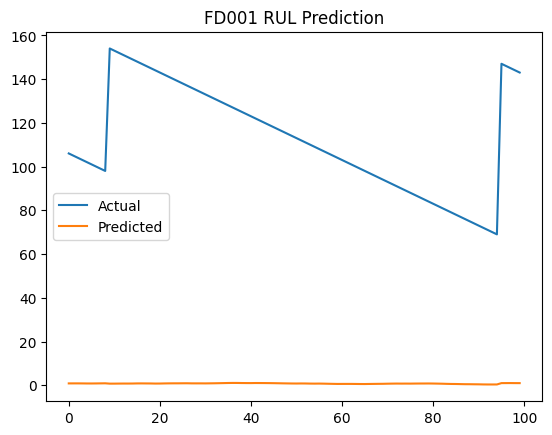

In [ ]:
import matplotlib.pyplot as plt

plt.plot(y_test_001[:100], label='Actual')
plt.plot(y_pred_001[:100], label='Predicted')
plt.title("FD001 RUL Prediction")
plt.legend()
plt.show()

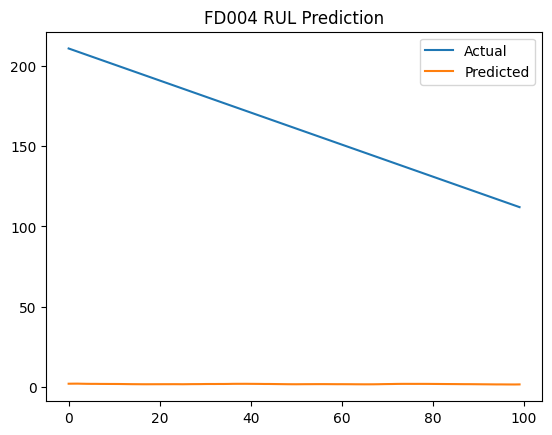

In [ ]:
plt.plot(y_test_004[:100], label='Actual')
plt.plot(y_pred_004[:100], label='Predicted')
plt.title("FD004 RUL Prediction")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_001 = np.sqrt(mean_squared_error(y_test_001, y_pred_001))
print("FD001 RMSE:", rmse_001)

FD001 RMSE: 131.81692293432965
